# Take_Home_Exercise_3

Predict whether a certain racer will finish in the top three in a particular race.

In [0]:
import pandas as pd

In [0]:
df_results = spark.read.csv("/Volumes/gr5069/raw/f1_data/results.csv", header=True)
display(df_results.limit(10))

resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
1,18,1,1,22,1,1,1,1,10,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
2,18,2,2,3,5,2,2,2,8,58,+5.478,5696094,41,3,1:27.739,217.586,1
3,18,3,3,7,7,3,3,3,6,58,+8.163,5698779,41,5,1:28.090,216.719,1
4,18,4,4,5,11,4,4,4,5,58,+17.181,5707797,58,7,1:28.603,215.464,1
5,18,5,1,23,3,5,5,5,4,58,+18.014,5708630,43,1,1:27.418,218.385,1
6,18,6,3,8,13,6,6,6,3,57,\N,\N,50,14,1:29.639,212.974,11
7,18,7,5,14,17,7,7,7,2,55,\N,\N,54,8,1:29.534,213.224,5
8,18,8,6,1,15,8,8,8,1,53,\N,\N,20,4,1:27.903,217.180,5
9,18,9,2,4,2,\N,R,9,0,47,\N,\N,15,9,1:28.753,215.100,4
10,18,10,7,12,18,\N,R,10,0,43,\N,\N,23,13,1:29.558,213.166,3


In [0]:
df_races = spark.read.csv("/Volumes/gr5069/raw/f1_data/races.csv", header=True)
display(df_races.limit(10))

raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
6,2009,6,6,Monaco Grand Prix,2009-05-24,12:00:00,http://en.wikipedia.org/wiki/2009_Monaco_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
7,2009,7,5,Turkish Grand Prix,2009-06-07,12:00:00,http://en.wikipedia.org/wiki/2009_Turkish_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
8,2009,8,9,British Grand Prix,2009-06-21,12:00:00,http://en.wikipedia.org/wiki/2009_British_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
9,2009,9,20,German Grand Prix,2009-07-12,12:00:00,http://en.wikipedia.org/wiki/2009_German_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
10,2009,10,11,Hungarian Grand Prix,2009-07-26,12:00:00,http://en.wikipedia.org/wiki/2009_Hungarian_Grand_Prix,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [0]:
from pyspark.sql.functions import when, col

df_model = (
    df_results
    .join(
        df_races.select("raceId", "year", "round", "circuitId"),
        on="raceId",
        how="left"
    )
    .withColumn("is_podium", when(col("positionOrder") <= 3, 1).otherwise(0))
    .select(
        "grid",
        "constructorId",
        "driverId",
        "circuitId",
        "year",
        "round",
        "is_podium"
    )
    .dropna()
)

display(df_model.limit(10))

grid,constructorId,driverId,circuitId,year,round,is_podium
1,1,1,1,2008,1,1
5,2,2,1,2008,1,1
7,3,3,1,2008,1,1
11,4,4,1,2008,1,0
3,1,5,1,2008,1,0
13,3,6,1,2008,1,0
17,5,7,1,2008,1,0
15,6,8,1,2008,1,0
2,2,9,1,2008,1,0
18,7,10,1,2008,1,0


In [0]:
df = df_model.toPandas()

X = df.drop("is_podium", axis=1)
y = df["is_podium"]

In [0]:
print(df["is_podium"].value_counts())
print(df["is_podium"].value_counts(normalize=True))

is_podium
0    23362
1     3397
Name: count, dtype: int64
is_podium
0    0.873052
1    0.126948
Name: proportion, dtype: float64


Perform a train/test split.

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [0]:
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [0]:
experiment_name = "/Users/xs2591@columbia.edu/take_home_exercise_f1_podium_prediction"
mlflow.set_experiment(experiment_name)

experiment = mlflow.get_experiment_by_name(experiment_name)
experiment_id = experiment.experiment_id

print("Experiment ID:", experiment_id)

2026/04/13 03:28:41 INFO mlflow.tracking.fluent: Experiment with name '/Users/xs2591@columbia.edu/take_home_exercise_f1_podium_prediction' does not exist. Creating a new experiment.


Experiment ID: 2373701489074612


In [0]:
def log_rf_classifier(experiment_id, run_name, params, X_train, X_test, y_train, y_test):
    import os
    import tempfile
    import pandas as pd
    import matplotlib.pyplot as plt
    import mlflow.sklearn

    with mlflow.start_run(experiment_id=experiment_id, run_name=run_name) as run:
        # 1. train model
        rf = RandomForestClassifier(**params)
        rf.fit(X_train, y_train)

        # 2. predictions
        y_pred = rf.predict(X_test)
        y_prob = rf.predict_proba(X_test)[:, 1]

        # 3. log model
        mlflow.sklearn.log_model(rf, "random-forest-classifier-model")

        # 4. log params
        for param, value in params.items():
            mlflow.log_param(param, value)

        # 5. calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_prob)

        # 6. log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        print(f"accuracy: {accuracy}")
        print(f"precision: {precision}")
        print(f"recall: {recall}")
        print(f"f1_score: {f1}")
        print(f"roc_auc: {roc_auc}")

        # 7. create artifacts
        with tempfile.TemporaryDirectory() as tmp_dir:
            # artifact 1: confusion matrix plot
            cm = confusion_matrix(y_test, y_pred)

            plt.figure(figsize=(6, 4))
            plt.imshow(cm, interpolation='nearest')
            plt.title("Confusion Matrix")
            plt.colorbar()
            plt.xticks([0, 1], ["Not Podium", "Podium"])
            plt.yticks([0, 1], ["Not Podium", "Podium"])
            plt.xlabel("Predicted")
            plt.ylabel("Actual")

            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    plt.text(j, i, cm[i, j], ha="center", va="center")

            cm_path = os.path.join(tmp_dir, "confusion_matrix.png")
            plt.tight_layout()
            plt.savefig(cm_path)
            plt.show() 
            plt.close()

            mlflow.log_artifact(cm_path)

            # artifact 2: feature importance csv
            feature_importance_df = pd.DataFrame({
                "feature": X_train.columns,
                "importance": rf.feature_importances_
            }).sort_values("importance", ascending=False)

            fi_csv_path = os.path.join(tmp_dir, "feature_importance.csv")
            feature_importance_df.to_csv(fi_csv_path, index=False)
            mlflow.log_artifact(fi_csv_path)

            # artifact 3: feature importance plot
            plt.figure(figsize=(8, 5))
            plt.bar(feature_importance_df["feature"], feature_importance_df["importance"])
            plt.xticks(rotation=45)
            plt.title("Feature Importances")
            plt.tight_layout()

            fi_plot_path = os.path.join(tmp_dir, "feature_importance.png")
            plt.savefig(fi_plot_path)
            plt.show() 
            plt.close()

            mlflow.log_artifact(fi_plot_path)

            # artifact 4: classification report csv
            report_dict = classification_report(y_test, y_pred, output_dict=True)
            report_df = pd.DataFrame(report_dict).transpose()

            report_csv_path = os.path.join(tmp_dir, "classification_report.csv")
            report_df.to_csv(report_csv_path)
            mlflow.log_artifact(report_csv_path)

        print(f"Run ID: {run.info.run_id}")
        return run.info.run_id

2026/04/13 03:28:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-c67700f8412d4b4a8c76dce9e2a6bc42?o=7474645003041195
2026/04/13 03:28:46 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.89050822122571
precision: 0.7048458149779736
recall: 0.23564064801178203
f1_score: 0.35320088300220753
roc_auc: 0.8932105187353035


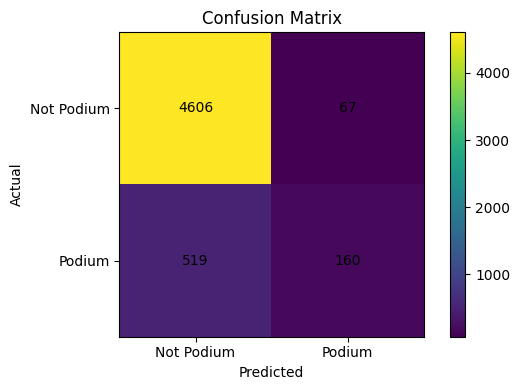

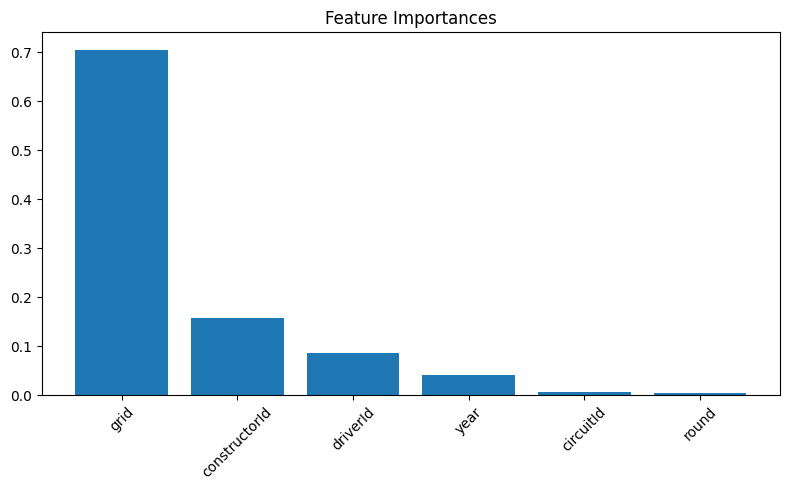

Run ID: 9a34e893d11f4bc9a44100866f53c94d


In [0]:
params = {
    "n_estimators": 100,
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": 42
}

run_id_1 = log_rf_classifier(
    experiment_id,
    "run_1",
    params,
    X_train, X_test, y_train, y_test
)

In [0]:
param_grid = [
    {"n_estimators": 50,  "max_depth": 3,  "min_samples_split": 2, "min_samples_leaf": 1, "random_state": 42},
    {"n_estimators": 100, "max_depth": 5,  "min_samples_split": 2, "min_samples_leaf": 1, "random_state": 42},
    {"n_estimators": 200, "max_depth": 8,  "min_samples_split": 2, "min_samples_leaf": 1, "random_state": 42},
    {"n_estimators": 300, "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1, "random_state": 42},
    {"n_estimators": 100, "max_depth": 5,  "min_samples_split": 5, "min_samples_leaf": 1, "random_state": 42},
    {"n_estimators": 200, "max_depth": 8,  "min_samples_split": 5, "min_samples_leaf": 2, "random_state": 42},
    {"n_estimators": 300, "max_depth": 12, "min_samples_split": 10, "min_samples_leaf": 2, "random_state": 42},
    {"n_estimators": 500, "max_depth": 15, "min_samples_split": 2, "min_samples_leaf": 1, "random_state": 42},
    {"n_estimators": 150, "max_depth": 6,  "min_samples_split": 4, "min_samples_leaf": 2, "random_state": 42},
    {"n_estimators": 250, "max_depth": None, "min_samples_split": 2, "min_samples_leaf": 1, "random_state": 42}
]

2026/04/13 03:28:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-dd0c9565874f4d6490756586196ab074?o=7474645003041195
2026/04/13 03:28:54 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8759342301943199
precision: 0.6415094339622641
recall: 0.050073637702503684
f1_score: 0.09289617486338798
roc_auc: 0.8722195976195151


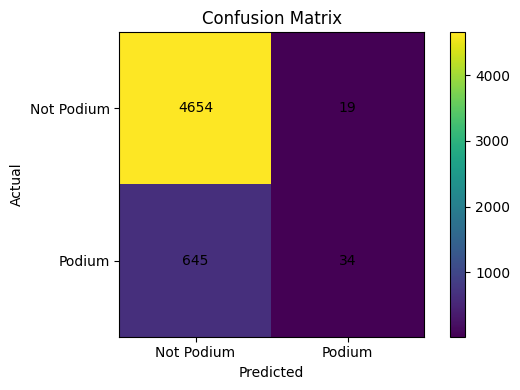

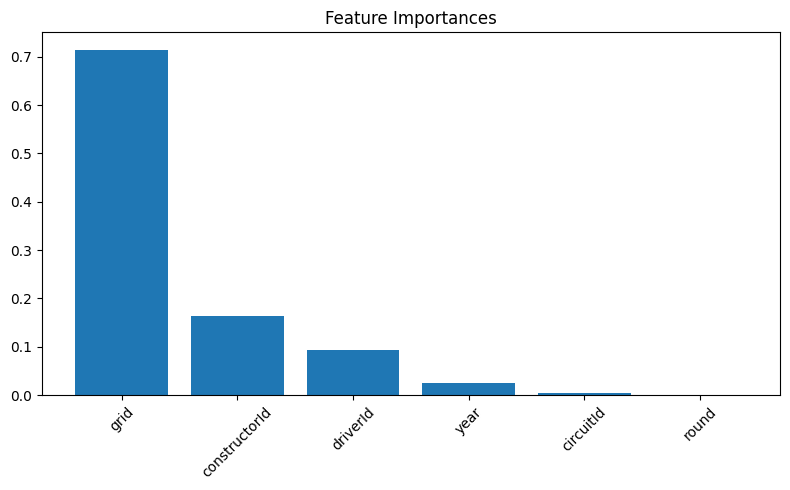

Run ID: 784c0353b5d6439b94740016490e65b3


2026/04/13 03:28:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-080d1868dd4f4e838263703dc6ff1aac?o=7474645003041195
2026/04/13 03:29:02 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.89050822122571
precision: 0.7048458149779736
recall: 0.23564064801178203
f1_score: 0.35320088300220753
roc_auc: 0.8932105187353035


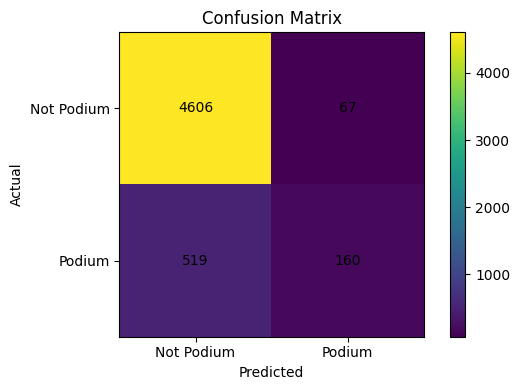

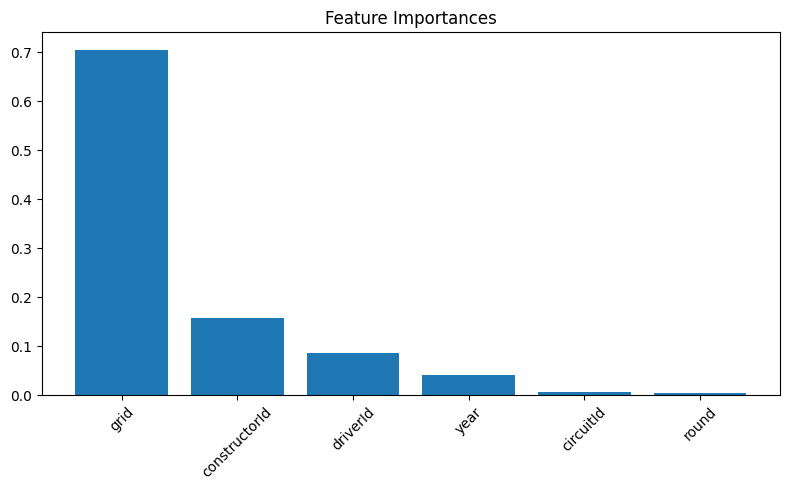

Run ID: 8bda34e72e1a45f3ab3b779b0a6ca9f8


2026/04/13 03:29:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-adb39e9e3a5d41ad8ff79c3a6094bfe3?o=7474645003041195
2026/04/13 03:29:11 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8968609865470852
precision: 0.6720867208672087
recall: 0.36524300441826213
f1_score: 0.4732824427480916
roc_auc: 0.9034005081048746


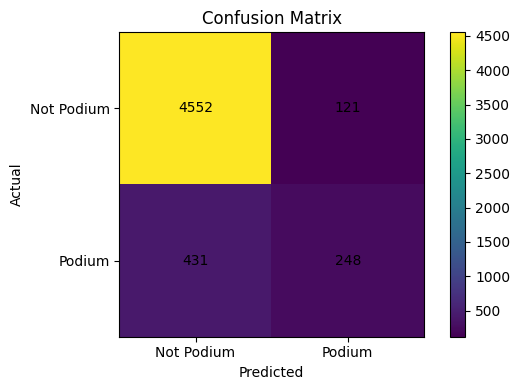

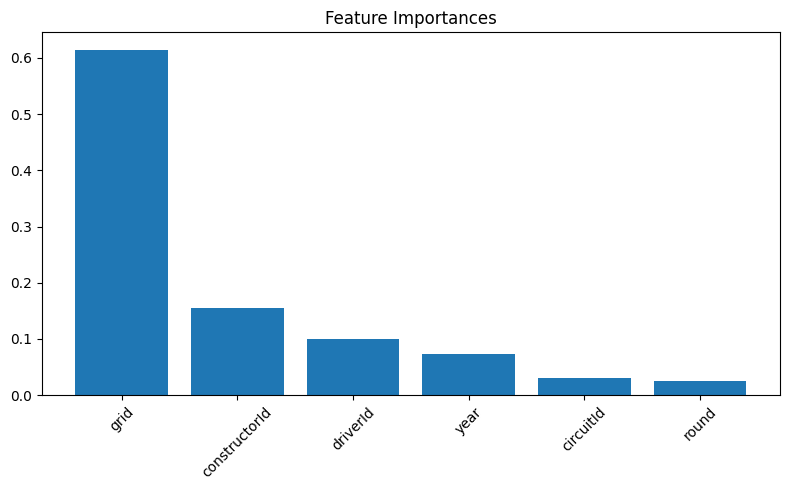

Run ID: a1884cc27587459a93f118dc566d5e66


2026/04/13 03:29:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-8cc4438173b442a883d82f39b81b59f2?o=7474645003041195
2026/04/13 03:29:23 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8974215246636771
precision: 0.6585365853658537
recall: 0.39764359351988215
f1_score: 0.49586776859504134
roc_auc: 0.9052120617705761


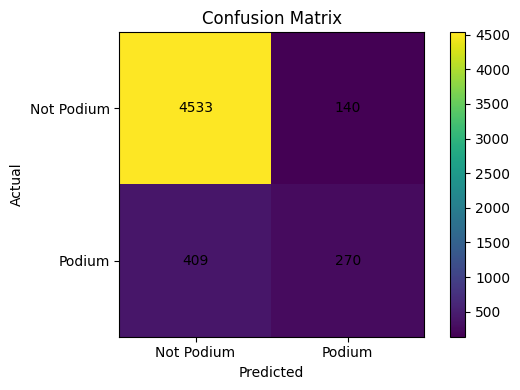

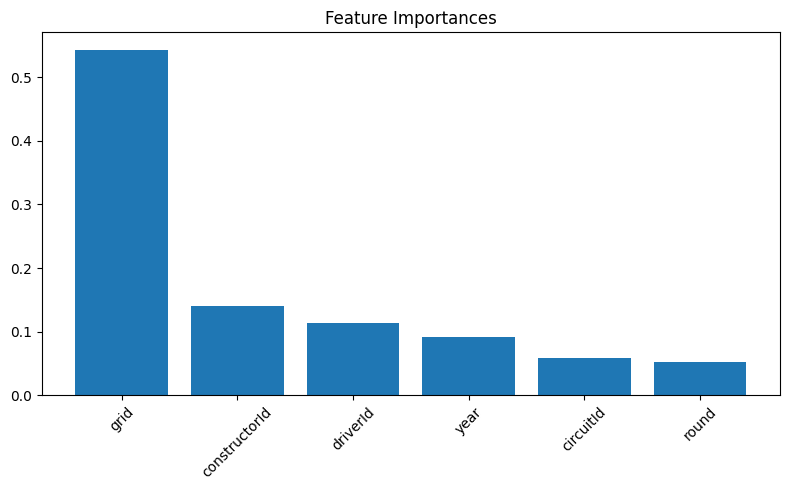

Run ID: 55c0ea3d230c46ed935f09fcab5f4014


2026/04/13 03:29:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-965cb3712bfe4d0c9377bbde6f27bf73?o=7474645003041195
2026/04/13 03:29:31 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8892002989536621
precision: 0.7009345794392523
recall: 0.22091310751104565
f1_score: 0.335946248600224
roc_auc: 0.893583355893711


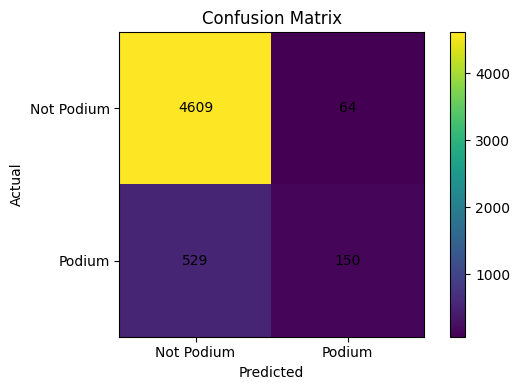

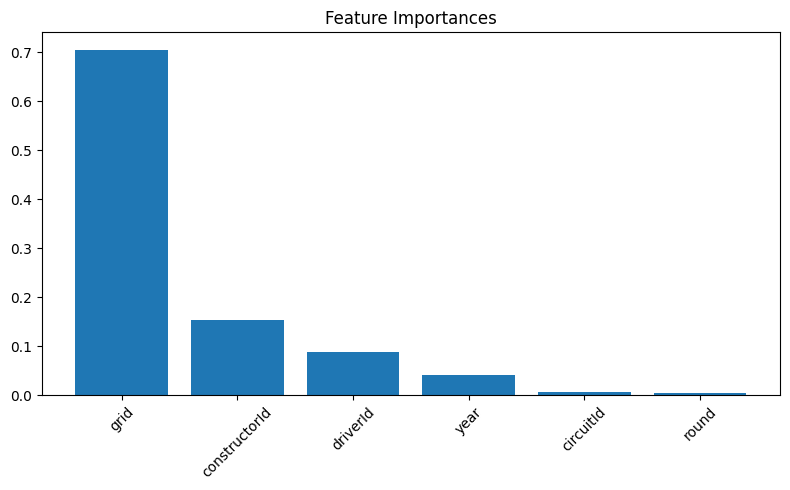

Run ID: 09a6d0640bc143d8b88e8b5bd38e591b


2026/04/13 03:29:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-6bddf0601fe04308a38fbefaf4b7f9b4?o=7474645003041195
2026/04/13 03:29:41 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8976083707025411
precision: 0.675603217158177
recall: 0.3711340206185567
f1_score: 0.4790874524714829
roc_auc: 0.9031234803261426


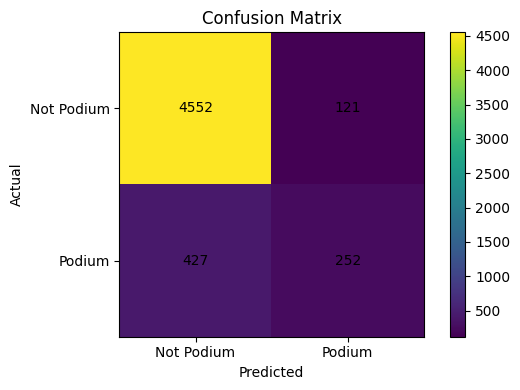

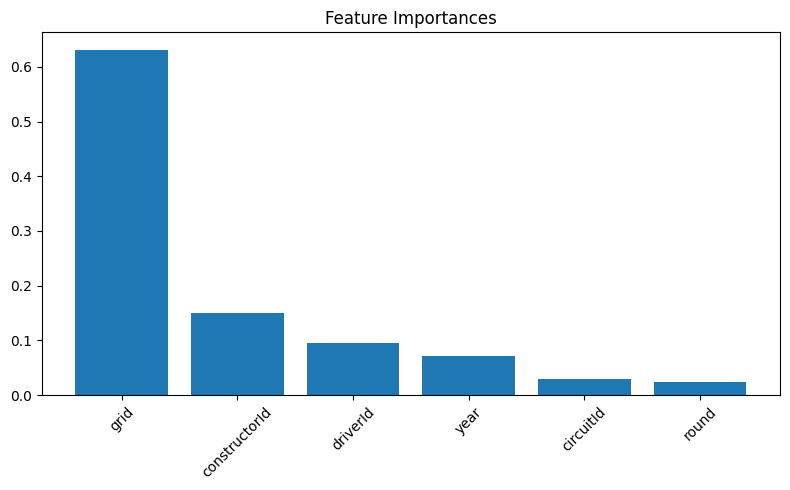

Run ID: fbb49f192ea641b083a30e2b4fe4c2e3


2026/04/13 03:29:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-849ab4d1649340bba654f5a7f5136a48?o=7474645003041195
2026/04/13 03:29:53 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8948056801195815
precision: 0.638755980861244
recall: 0.39322533136966126
f1_score: 0.48678213309024615
roc_auc: 0.9049170697331551


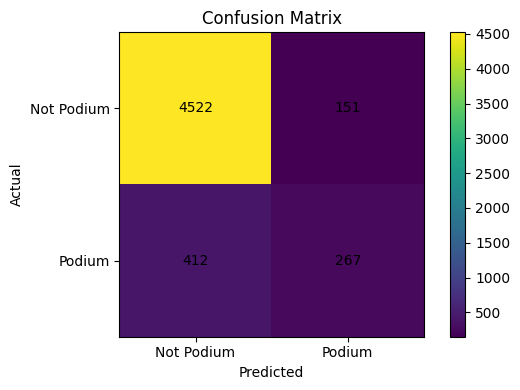

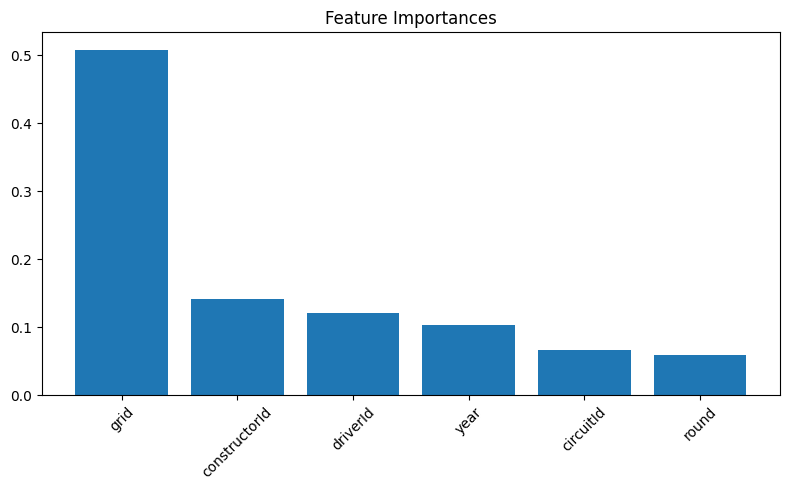

Run ID: fd9fc8d427b5422aa1f13947d3c602d3


2026/04/13 03:30:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-6a15fd6250ea45c29ac544333ea9c1af?o=7474645003041195
2026/04/13 03:30:11 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8890134529147982
precision: 0.5955056179775281
recall: 0.390279823269514
f1_score: 0.47153024911032027
roc_auc: 0.8982892037641741


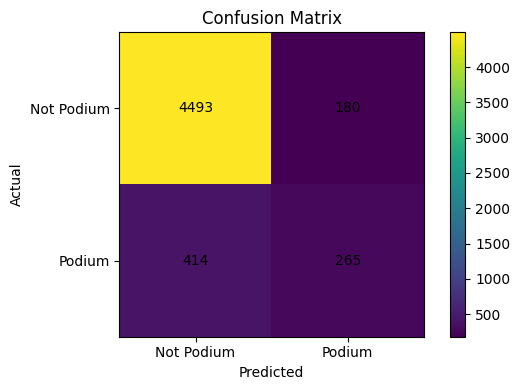

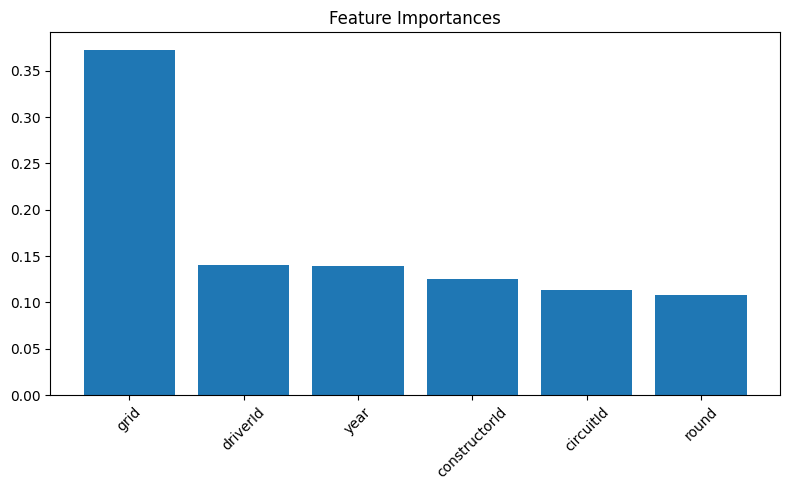

Run ID: 689f732209f042eea381842ab9ad5e19


2026/04/13 03:30:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-a2655176f8ba49239cbe9816b2ce8f60?o=7474645003041195
2026/04/13 03:30:23 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8946188340807175
precision: 0.6780185758513931
recall: 0.3225331369661267
f1_score: 0.437125748502994
roc_auc: 0.8972742231482396


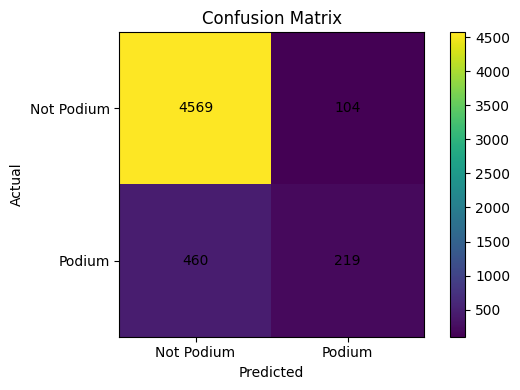

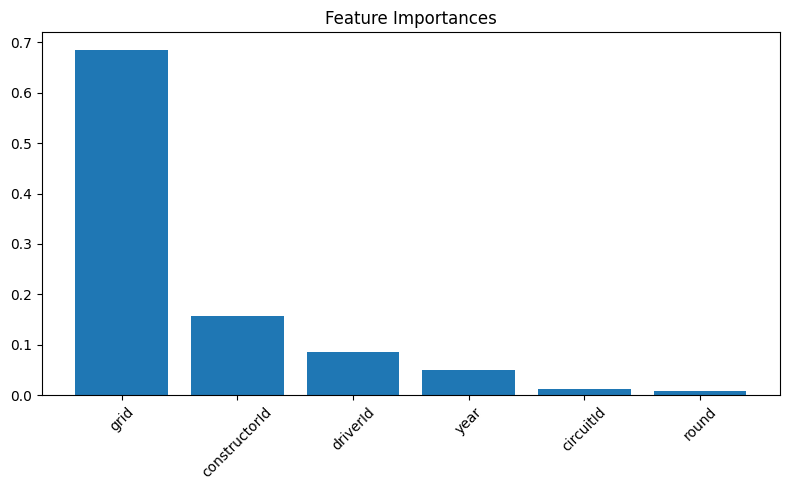

Run ID: 8c29c799e4794ea080fd14c9a96dfdb3


2026/04/13 03:30:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f11e6b56-7522.cloud.databricks.com/ml/experiments/2373701489074612/models/m-18e3453e9ca6418c81c28df184366adf?o=7474645003041195
2026/04/13 03:30:36 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


accuracy: 0.8813527653213752
precision: 0.5466101694915254
recall: 0.3799705449189985
f1_score: 0.4483058210251955
roc_auc: 0.8912111282594494


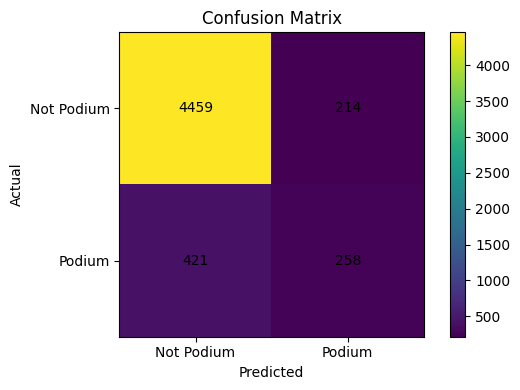

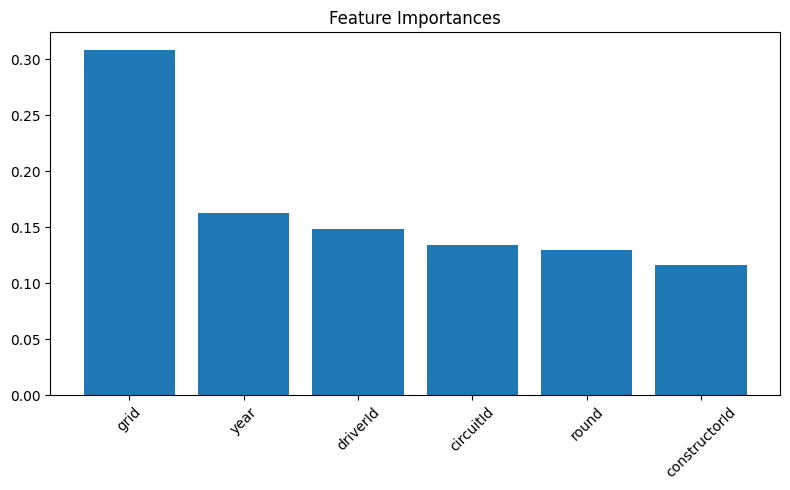

Run ID: be9b1eb1e1aa44d69cd188a252b462c8


In [0]:
run_ids = []

for i, params in enumerate(param_grid, start=1):
    run_id = log_rf_classifier(
        experiment_id,
        f"run_{i}",
        params,
        X_train, X_test, y_train, y_test
    )
    run_ids.append(run_id)

In [0]:
runs_df = mlflow.search_runs(experiment_ids=[experiment_id])
display(runs_df)

run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.roc_auc,metrics.recall,metrics.accuracy,metrics.precision,metrics.f1_score,params.random_state,params.min_samples_split,params.n_estimators,params.max_depth,params.min_samples_leaf,tags.mlflow.databricks.cluster.id,tags.mlflow.databricks.notebookID,tags.mlflow.databricks.cluster.info,tags.mlflow.databricks.notebookPath,tags.mlflow.source.name,tags.mlflow.databricks.workspaceID,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.runColor,tags.mlflow.databricks.notebook.commandID,tags.mlflow.databricks.webappURL,tags.mlflow.databricks.workspaceURL,tags.mlflow.source.type,tags.mlflow.databricks.cluster.libraries,tags.mlflow.databricks.notebookRevisionID
be9b1eb1e1aa44d69cd188a252b462c8,2373701489074612,FINISHED,dbfs:/databricks/mlflow-tracking/2373701489074612/be9b1eb1e1aa44d69cd188a252b462c8/artifacts,2026-04-13T03:30:27.045Z,2026-04-13T03:30:43.272Z,0.8912111282594494,0.3799705449189985,0.8813527653213752,0.5466101694915254,0.4483058210251955,42,2,250,None,1,0413-021036-kpf3logo-v2n,2373701489074486,"{""cluster_name"":"""",""spark_version"":""client.5.1-scala2.13"",""autotermination_minutes"":120}",/Users/xs2591@columbia.edu/take_home_exercise_3,/Users/xs2591@columbia.edu/take_home_exercise_3,7474645003041195,xs2591@columbia.edu,run_10,#229487,1776045172075_6212783032614305773_f70f4dd5ba8c4532950e9b272eacd21a,https://dbc-f11e6b56-7522.cloud.databricks.com,https://dbc-f11e6b56-7522.cloud.databricks.com,NOTEBOOK,"{""installable"":[],""redacted"":[]}",null
8c29c799e4794ea080fd14c9a96dfdb3,2373701489074612,FINISHED,dbfs:/databricks/mlflow-tracking/2373701489074612/8c29c799e4794ea080fd14c9a96dfdb3/artifacts,2026-04-13T03:30:18.897Z,2026-04-13T03:30:26.932Z,0.8972742231482396,0.3225331369661267,0.8946188340807175,0.6780185758513931,0.437125748502994,42,4,150,6,2,0413-021036-kpf3logo-v2n,2373701489074486,"{""cluster_name"":"""",""spark_version"":""client.5.1-scala2.13"",""autotermination_minutes"":120}",/Users/xs2591@columbia.edu/take_home_exercise_3,/Users/xs2591@columbia.edu/take_home_exercise_3,7474645003041195,xs2591@columbia.edu,run_9,#5bc5db,1776045172075_6212783032614305773_f70f4dd5ba8c4532950e9b272eacd21a,https://dbc-f11e6b56-7522.cloud.databricks.com,https://dbc-f11e6b56-7522.cloud.databricks.com,NOTEBOOK,"{""installable"":[],""redacted"":[]}",1776051027010
689f732209f042eea381842ab9ad5e19,2373701489074612,FINISHED,dbfs:/databricks/mlflow-tracking/2373701489074612/689f732209f042eea381842ab9ad5e19/artifacts,2026-04-13T03:29:57.601Z,2026-04-13T03:30:18.788Z,0.8982892037641741,0.390279823269514,0.8890134529147982,0.5955056179775281,0.47153024911032027,42,2,500,15,1,0413-021036-kpf3logo-v2n,2373701489074486,"{""cluster_name"":"""",""spark_version"":""client.5.1-scala2.13"",""autotermination_minutes"":120}",/Users/xs2591@columbia.edu/take_home_exercise_3,/Users/xs2591@columbia.edu/take_home_exercise_3,7474645003041195,xs2591@columbia.edu,run_8,#edb732,1776045172075_6212783032614305773_f70f4dd5ba8c4532950e9b272eacd21a,https://dbc-f11e6b56-7522.cloud.databricks.com,https://dbc-f11e6b56-7522.cloud.databricks.com,NOTEBOOK,"{""installable"":[],""redacted"":[]}",1776051018868
fd9fc8d427b5422aa1f13947d3c602d3,2373701489074612,FINISHED,dbfs:/databricks/mlflow-tracking/2373701489074612/fd9fc8d427b5422aa1f13947d3c602d3/artifacts,2026-04-13T03:29:44.249Z,2026-04-13T03:29:57.479Z,0.9049170697331551,0.39322533136966126,0.8948056801195815,0.638755980861244,0.48678213309024615,42,10,300,12,2,0413-021036-kpf3logo-v2n,2373701489074486,"{""cluster_name"":"""",""spark_version"":""client.5.1-scala2.13"",""autotermination_minutes"":120}",/Users/xs2591@columbia.edu/take_home_exercise_3,/Users/xs2591@columbia.edu/take_home_exercise_3,7474645003041195,xs2591@columbia.edu,run_7,#c565c7,1776045172075_6212783032614305773_f70f4dd5ba8c4532950e9b272eacd21a,https://dbc-f11e6b56-7522.cloud.databricks.com,https://dbc-f11e6b56-7522.cloud.databricks.com,NOTEBOOK,"{""installable"":[],""redacted"":[]}"

In [0]:
runs_df[[
    "run_id",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1_score",
    "metrics.roc_auc",
    "params.n_estimators",
    "params.max_depth",
    "params.min_samples_split",
    "params.min_samples_leaf"
]].sort_values("metrics.f1_score", ascending=False)

,run_id,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_score,metrics.roc_auc,params.n_estimators,params.max_depth,params.min_samples_split,params.min_samples_leaf
6,55c0ea3d230c46ed935f09fcab5f4014,0.897422,0.658537,0.397644,0.495868,0.905212,300,10,2,1
3,fd9fc8d427b5422aa1f13947d3c602d3,0.894806,0.638756,0.393225,0.486782,0.904917,300,12,10,2
4,fbb49f192ea641b083a30e2b4fe4c2e3,0.897608,0.675603,0.371134,0.479087,0.903123,200,8,5,2
7,a1884cc27587459a93f118dc566d5e66,0.896861,0.672087,0.365243,0.473282,0.903401,200,8,2,1
2,689f732209f042eea381842ab9ad5e19,0.889013,0.595506,0.390280,0.471530,0.898289,500,15,2,1
0,be9b1eb1e1aa44d69cd188a252b462c8,0.881353,0.546610,0.379971,0.448306,0.891211,250,None,2,1
1,8c29c799e4794ea080fd14c9a96dfdb3,0.894619,0.678019,0.322533,0.437126,0.897274,150,6,4,2
10,9a34e893d11f4bc9a44100866f53c94d,0.890508,0.704846,0.235641,0.353201,0.893211,100,5,2,1
8,8bda34e72e1a45f3ab3b779b0a6ca9f8,0.890508,0.704846,0.235641,0.353201,0.893211,100,5,2,1
5,09a6d0640bc143d8b88e8b5bd38e591b,0.889200,0.700935,0.220913,0.335946,0.893583,100,5,5,1


I chose RandomForestClassifier because it handles nonlinear relationships well, supports multiple tunable hyperparameters, and provides interpretable feature importances that can be logged as MLflow artifacts.

I framed the task as a binary classification problem: predicting whether a driver finishes on the podium. This target is intuitive, easy to define using the F1 results dataset, and suitable for evaluating multiple classification metrics in MLflow.

Among all 10 MLflow runs, I selected the model with run_id 55c0ea3d230c46ed935f09fcab5f4014		 as the best-performing model.

This model achieved the highest F1-score (0.496) among all runs, along with strong recall (0.398) and a high ROC-AUC (0.905). I chose F1-score as the primary evaluation metric because the target variable (is_podium) is highly imbalanced: only a small fraction of observations correspond to podium finishes.

In such cases, accuracy can be misleading, as a model can achieve high accuracy by predicting the majority class (non-podium) most of the time. F1-score provides a better balance between precision and recall, making it more suitable for evaluating performance on the minority class.